# Objectives:

1. **Data Exploration and EDA**: Understand the dataset and identify risk factors.
2. **Data Preprocessing**: Clean data and engineer features.
3. **Model Implementation**: Train Random Forest, SVM, and XGBoost models.
4. **Model Comparison**: Evaluate and compare model performance.
5. **Scenario Prediction**: Predict risk for sample and synthetic scenarios.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

ModuleNotFoundError: No module named 'xgboost'

In [17]:
# Set visual style
sns.set(style="whitegrid")
%matplotlib inline

# Path to the dataset
data_path = "D:/DataSet/loan.csv"

# 1. Data Exploration and EDA

Loading a sample of the data for EDA...
Target distribution:
0    0.87138
1    0.12862
Name: target, dtype: float64


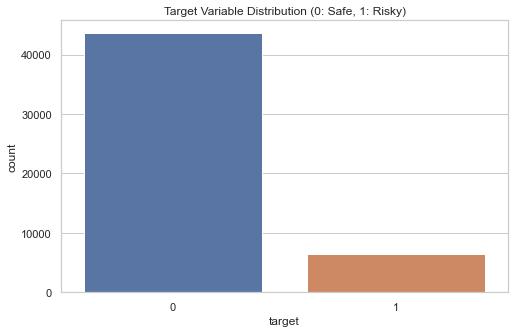

In [21]:
print("Loading a sample of the data for EDA...")
df_eda = pd.read_csv(data_path, low_memory=False, nrows=50000)

# Target Variable Mapping
bad_statuses = ['Charged Off', 'Default', 'Late (31-120 days)', 'Late (16-30 days)']
df_eda['target'] = df_eda['loan_status'].apply(lambda x: 1 if x in bad_statuses else 0)

print(f"Target distribution:\n{df_eda['target'].value_counts(normalize=True)}")

# Visualizing Target Distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='target', data=df_eda)
plt.title('Target Variable Distribution (0: Safe, 1: Risky)')
plt.show()

In [19]:
df_eda

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,1077501,1296599,5000.0,5000.0,4975.0,36 months,10.65,162.87,B,B2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1077430,1314167,2500.0,2500.0,2500.0,60 months,15.27,59.83,C,C4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1077175,1313524,2400.0,2400.0,2400.0,36 months,15.96,84.33,C,C5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1076863,1277178,10000.0,10000.0,10000.0,36 months,13.49,339.31,C,C1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1075358,1311748,3000.0,3000.0,3000.0,60 months,12.69,67.79,B,B5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,9784579,11636726,10800.0,10800.0,10800.0,60 months,14.47,253.94,C,C2,...,NaN,NaN,NaN,NaN,NaN,NaN,21100.0,NaN,NaN,NaN
49996,9706491,11558270,30000.0,30000.0,30000.0,60 months,14.47,705.38,C,C2,...,NaN,NaN,NaN,NaN,NaN,NaN,26300.0,NaN,NaN,NaN
49997,9804647,11656782,17000.0,17000.0,17000.0,60 months,17.57,427.73,D,D2,...,NaN,NaN,NaN,NaN,NaN,NaN,18600.0,NaN,NaN,NaN
49998,9824702,11676835,3000.0,3000.0,3000.0,36 months,13.98,102.51,C,C1,...,NaN,NaN,NaN,NaN,NaN,NaN,7200.0,NaN,NaN,NaN


In [44]:
df_eda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 75 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           50000 non-null  int64  
 1   member_id                    50000 non-null  int64  
 2   loan_amnt                    50000 non-null  float64
 3   funded_amnt                  50000 non-null  float64
 4   funded_amnt_inv              50000 non-null  float64
 5   term                         50000 non-null  object 
 6   int_rate                     50000 non-null  float64
 7   installment                  50000 non-null  float64
 8   grade                        50000 non-null  object 
 9   sub_grade                    50000 non-null  object 
 10  emp_title                    46915 non-null  object 
 11  emp_length                   48561 non-null  object 
 12  home_ownership               50000 non-null  object 
 13  annual_inc      

In [46]:
df_eda.describe()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,delinq_2yrs,...,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,target
count,5.000000e+04,5.000000e+04,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,4.999600e+04,50000.000000,49971.000000,...,0.0,0.0,0.0,0.0,0.0,7465.000000,0.0,0.0,0.0,50000.000000
mean,2.032561e+06,2.387589e+06,11644.863000,11416.759000,10835.313893,12.499200,342.394207,7.020171e+04,13.977975,0.175762,...,NaN,NaN,NaN,NaN,NaN,29443.935700,NaN,NaN,NaN,0.128620
std,3.279458e+06,3.796347e+06,7676.637581,7478.195384,7514.399816,3.893064,221.421318,6.197268e+04,7.003575,0.568454,...,NaN,NaN,NaN,NaN,NaN,27318.448376,NaN,NaN,NaN,0.334782
min,5.473400e+04,7.047300e+04,500.000000,500.000000,0.000000,5.420000,15.670000,1.896000e+03,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,0.000000
25%,5.218460e+05,6.745240e+05,6000.000000,5700.000000,5000.000000,9.700000,174.240000,4.200000e+04,8.680000,0.000000,...,NaN,NaN,NaN,NaN,NaN,13800.000000,NaN,NaN,NaN,0.000000
50%,7.122315e+05,9.049305e+05,10000.000000,10000.000000,9500.000000,12.420000,298.670000,6.000000e+04,13.970000,0.000000,...,NaN,NaN,NaN,NaN,NaN,22600.000000,NaN,NaN,NaN,0.000000
75%,9.873852e+05,1.210940e+06,15250.000000,15000.000000,14975.000000,14.980000,460.560000,8.499600e+04,19.290000,0.000000,...,NaN,NaN,NaN,NaN,NaN,37200.000000,NaN,NaN,NaN,0.000000
max,1.023482e+07,1.209697e+07,35000.000000,35000.000000,35000.000000,26.060000,1407.010000,6.000000e+06,34.950000,15.000000,...,NaN,NaN,NaN,NaN,NaN,527300.000000,NaN,NaN,NaN,1.000000


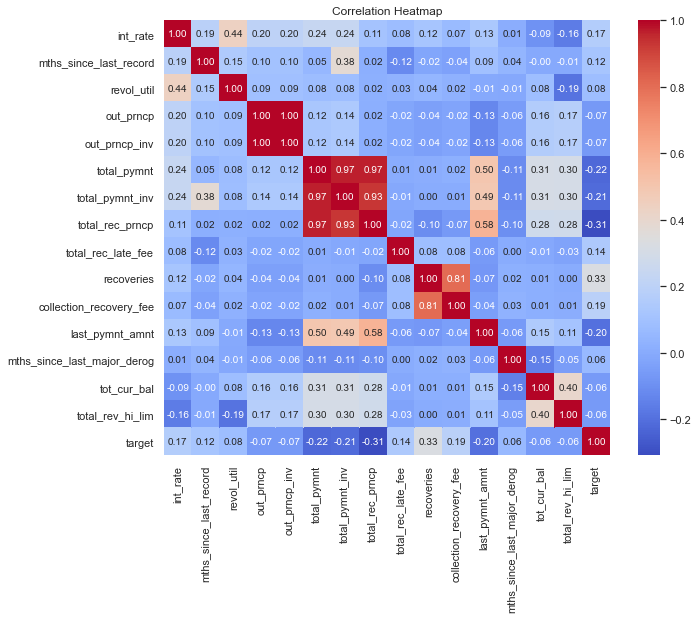

In [22]:
# Correlation Heatmap (Top Features)

numerical_cols = df_eda.select_dtypes(include=[np.number]).columns.tolist()
corr = df_eda[numerical_cols].corr()
top_corr_features = corr.index[abs(corr["target"])>0.05]

plt.figure(figsize=(10, 8))
sns.heatmap(df_eda[top_corr_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

# 2. Data Preprocessing

In [23]:
print("Loading and preprocessing data...")
df = pd.read_csv(data_path, low_memory=False, nrows=100000)

Loading and preprocessing data...


In [24]:
df

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,1077501,1296599,5000.0,5000.0,4975.0,36 months,10.65,162.87,B,B2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1077430,1314167,2500.0,2500.0,2500.0,60 months,15.27,59.83,C,C4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1077175,1313524,2400.0,2400.0,2400.0,36 months,15.96,84.33,C,C5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1076863,1277178,10000.0,10000.0,10000.0,36 months,13.49,339.31,C,C1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1075358,1311748,3000.0,3000.0,3000.0,60 months,12.69,67.79,B,B5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,6718306,8320617,3000.0,3000.0,3000.0,36 months,18.85,109.75,D,D3,...,NaN,NaN,NaN,NaN,NaN,NaN,4000.0,NaN,NaN,NaN
99996,6817526,3957101,25050.0,25050.0,25000.0,36 months,13.68,852.27,C,C1,...,NaN,NaN,NaN,NaN,NaN,NaN,48700.0,NaN,NaN,NaN
99997,6876234,8498329,19000.0,19000.0,18950.0,60 months,13.68,438.96,C,C1,...,NaN,NaN,NaN,NaN,NaN,NaN,33900.0,NaN,NaN,NaN
99998,6817614,8439653,7000.0,7000.0,7000.0,36 months,11.55,231.00,B,B3,...,NaN,NaN,NaN,NaN,NaN,NaN,49100.0,NaN,NaN,NaN


In [54]:
df.columns

Index(['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       'emp_length', 'home_ownership', 'annual_inc', 'verification_status',
       'pymnt_plan', 'purpose', 'dti', 'delinq_2yrs', 'earliest_cr_line',
       'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util',
       'total_acc', 'initial_list_status', 'collections_12_mths_ex_med',
       'policy_code', 'application_type', 'acc_now_delinq', 'tot_coll_amt',
       'tot_cur_bal', 'total_rev_hi_lim', 'target'],
      dtype='object')

In [25]:
# Target Mapping

df['target'] = df['loan_status'].apply(lambda x: 1 if x in bad_statuses else 0)

In [26]:
df['target']

0        0
1        1
2        0
3        0
4        0
        ..
99995    0
99996    0
99997    0
99998    0
99999    0
Name: target, Length: 100000, dtype: int64

In [27]:
# Feature Selection
missing_percent = df.isnull().mean()
cols_to_drop = missing_percent[missing_percent > 0.5].index.tolist()
df = df.drop(columns=cols_to_drop)

id_cols = ['id', 'member_id', 'url', 'title', 'zip_code', 'addr_state', 'emp_title']
df = df.drop(columns=[col for col in id_cols if col in df.columns])

leaky_cols = ['issue_d', 'loan_status', 'funded_amnt', 'funded_amnt_inv', 'out_prncp', 'out_prncp_inv', 
              'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 
              'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 
              'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d']
df = df.drop(columns=[col for col in leaky_cols if col in df.columns])

In [28]:
missing_percent

id                  0.00000
member_id           0.00000
loan_amnt           0.00000
funded_amnt         0.00000
funded_amnt_inv     0.00000
                     ...   
total_rev_hi_lim    0.42535
inq_fi              1.00000
total_cu_tl         1.00000
inq_last_12m        1.00000
target              0.00000
Length: 75, dtype: float64

In [29]:
# Handling Missing Values
for col in df.select_dtypes(include=[np.number]).columns:
    df[col] = df[col].fillna(df[col].median())
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna(df[col].mode()[0] if not df[col].mode().empty else "Unknown")

In [30]:
# Feature Engineering
if 'term' in df.columns:
    df['term'] = df['term'].str.extract('(\\d+)').astype(int)

if 'emp_length' in df.columns:
    emp_map = {'< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3, '4 years': 4,
               '5 years': 5, '6 years': 6, '7 years': 7, '8 years': 8, '9 years': 9,
               '10+ years': 10, 'Unknown': 0}
    df['emp_length'] = df['emp_length'].map(emp_map).fillna(0)

In [31]:
# Encoding
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col].astype(str))

In [32]:
# Train-Test Split
X = df.drop('target', axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Data split: {X_train.shape[0]} training samples, {X_test.shape[0]} test samples.")

Data split: 80000 training samples, 20000 test samples.


# 3. Model Implementation and Comparison

In [33]:
results = []

def evaluate_model(model, name, X_train, X_test, y_train, y_test):
    print(f"Training {name}...")
    start_time = time.time()
    model.fit(X_train, y_train)
    end_time = time.time()
    
    y_pred = model.predict(X_test)
    try:
        y_prob = model.predict_proba(X_test)[:, 1]
    except AttributeError:
        y_prob = model.decision_function(X_test)
        
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    
    return {'Model': name, 'Accuracy': acc, 'F1-Score': f1, 'ROC-AUC': roc_auc, 'Time (s)': end_time - start_time}

In [35]:
# 1. Random Forest

results.append(evaluate_model(RandomForestClassifier(n_estimators=100, random_state=42), 
                              'Random Forest', X_train, X_test, y_train, y_test))

Training Random Forest...


In [36]:
X_train

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,...,revol_util,total_acc,initial_list_status,collections_12_mths_ex_med,policy_code,application_type,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim
73586,4375.0,36,12.99,147.39,1,8,2,4,30000.0,2,...,26.1,20.0,1,0.0,1.0,0,0.0,195.0,21510.0,17400.0
41648,3000.0,36,14.18,102.80,4,20,0,4,33000.0,0,...,106.1,17.0,0,0.0,1.0,0,0.0,0.0,88378.0,23000.0
45922,13000.0,36,15.61,454.55,2,13,10,4,71000.0,2,...,82.0,16.0,1,0.0,1.0,0,0.0,0.0,23525.0,16800.0
33331,7000.0,36,13.92,238.96,2,13,3,0,63000.0,0,...,17.6,16.0,0,0.0,1.0,0,0.0,0.0,88378.0,23000.0
34722,20000.0,36,11.83,662.68,1,7,5,4,72000.0,0,...,28.6,13.0,0,0.0,1.0,0,0.0,0.0,88378.0,23000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49088,7200.0,36,14.47,247.73,2,11,1,0,58000.0,1,...,88.7,23.0,0,0.0,1.0,0,0.0,127.0,39058.0,13300.0
26115,4000.0,60,11.12,87.21,1,7,2,4,48000.0,0,...,1.0,15.0,0,0.0,1.0,0,0.0,0.0,88378.0,23000.0
31370,7000.0,36,7.88,218.97,0,4,2,4,42000.0,1,...,40.5,16.0,0,0.0,1.0,0,0.0,0.0,88378.0,23000.0
66424,12000.0,36,6.62,368.45,0,1,5,4,120000.0,2,...,40.4,12.0,1,0.0,1.0,0,0.0,0.0,23810.0,23700.0


In [37]:
# 2. Linear SVM
results.append(evaluate_model(LinearSVC(random_state=42, max_iter=2000), 
                              'SVM (Linear)', X_train, X_test, y_train, y_test))

Training SVM (Linear)...


C:\Users\AMARJEET\AppData\Roaming\Python\Python38\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
C:\Users\AMARJEET\AppData\Roaming\Python\Python38\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [38]:
# 3. XGBoost
results.append(evaluate_model(XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, eval_metric='logloss'), 
                              'XGBoost', X_train, X_test, y_train, y_test))

Training XGBoost...


In [39]:
df_results = pd.DataFrame(results)


In [40]:
df_results

,Model,Accuracy,F1-Score,ROC-AUC,Time (s)
0,Random Forest,0.8779,0.000000,0.664353,49.120339
1,SVM (Linear),0.3226,0.189713,0.450736,59.746676
2,XGBoost,0.8778,0.001634,0.694766,0.726640


# Plot 1: Accuracy Comparison

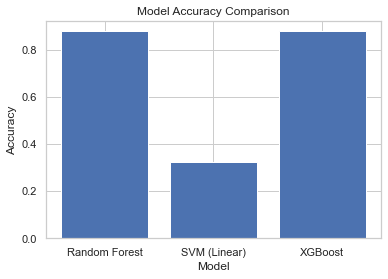

In [47]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(df_results['Model'], df_results['Accuracy'])
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.show()

# Plot 2: F1-Score Comparison

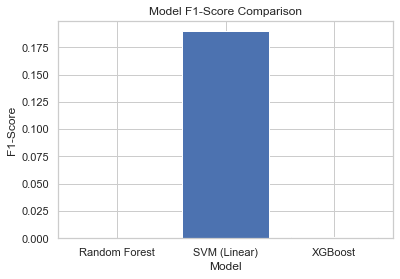

In [48]:
plt.figure()
plt.bar(df_results['Model'], df_results['F1-Score'])
plt.title("Model F1-Score Comparison")
plt.xlabel("Model")
plt.ylabel("F1-Score")
plt.show()

# Plot 3: ROC-AUC Comparison

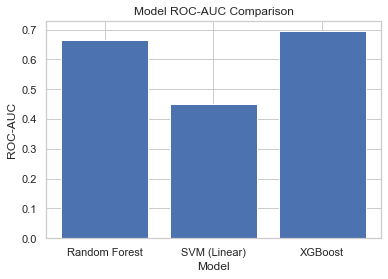

In [49]:
plt.figure()
plt.bar(df_results['Model'], df_results['ROC-AUC'])
plt.title("Model ROC-AUC Comparison")
plt.xlabel("Model")
plt.ylabel("ROC-AUC")
plt.show()

# Plot 4: Training Time Comparison

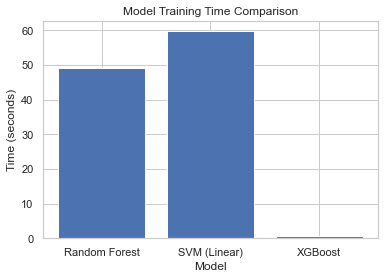

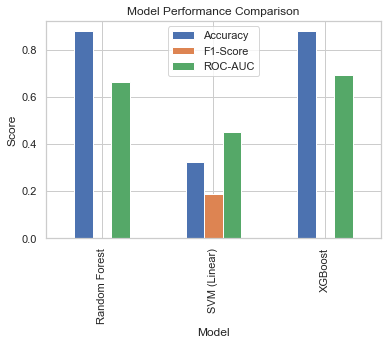

In [51]:
plt.figure()
plt.bar(df_results['Model'], df_results['Time (s)'])
plt.title("Model Training Time Comparison")
plt.xlabel("Model")
plt.ylabel("Time (seconds)")
plt.show()



metrics = ['Accuracy', 'F1-Score', 'ROC-AUC']

df_results.set_index('Model')[metrics].plot(kind='bar')
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.show()

# 4. Scenario Prediction

In [41]:
# Using XGBoost for scenario testing
best_model = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, eval_metric='logloss')
best_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [43]:
# Create synthetic scenarios
scenario_base = X_test.iloc[0:1].copy()

# 1. High Risk Applicant
risky_app = scenario_base.copy()
risky_app['annual_inc'] = X_train['annual_inc'].min()
risky_app['dti'] = 40.0
risky_app['int_rate'] = X_train['int_rate'].max()

# 2. Low Risk Applicant
safe_app = scenario_base.copy()
safe_app['annual_inc'] = X_train['annual_inc'].max() * 0.8
safe_app['dti'] = 5.0
safe_app['int_rate'] = X_train['int_rate'].min()

for name, app in [("Risky", risky_app), ("Safe", safe_app)]:
    prob = best_model.predict_proba(app)[0, 1]
    print(f"{name} Scenario Probability of Risk: {prob:.4f}")

Risky Scenario Probability of Risk: 0.4935
Safe Scenario Probability of Risk: 0.0730
